数据分析的流程
1. 对接需求
2. 获取数据（sql，爬虫，需求方数据）
3. 数据清洗（缺失值处理，异常值处理，重复值处理）
4. 分析
5. 建模
6. 可视化

# 1 获取数据

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import datetime
import time
import seaborn as sns
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = 'SimHei'
import warnings
warnings.filterwarnings('ignore')

In [26]:
# 读数据
df = pd.read_csv('拼多多.csv')
df.head()

,用户ID,用户姓名,商品ID,商品名称,商品类别,单价,购买时间,购买数量,消费金额,用户城市,用户性别,用户年龄
0,U7559,施光善,P32724,香水,美妆,809.99,2024-08-15 13:24:49,2,1619.98,成都,女,28
1,U5784,华军盛,P38500,篮球,运动,436.85,2024-07-08 22:34:38,1,436.85,深圳,男,31
2,U3309,唐子,P72120,芭比娃娃,玩具,649.23,2024-09-03 12:14:14,1,649.23,北京,男,51
3,U2872,闵功,P68477,毛绒玩具,玩具,674.04,2024-03-11 09:12:45,4,2696.16,深圳,女,31
4,U3141,谢乐平,P14776,笔记本电脑,电子产品,3759.34,2024-08-22 06:16:49,4,15037.36,西安,男,33


# 2 数据清洗
处理顺序：重复值->缺失值->异常值
1. 找到异常值的方法:
1. 99%的人群是正常的，1%异常的/大于300的人一刀切
2. Q3-Q1=IQRQ1-1.5IQRupper Q3+1.5IQRtop
3. 统计学的角度:一组数据的三倍标准差
4. 业务（以业务为主）


In [27]:
df

,用户ID,用户姓名,商品ID,商品名称,商品类别,单价,购买时间,购买数量,消费金额,用户城市,用户性别,用户年龄
0,U7559,施光善,P32724,香水,美妆,809.99,2024-08-15 13:24:49,2,1619.98,成都,女,28
1,U5784,华军盛,P38500,篮球,运动,436.85,2024-07-08 22:34:38,1,436.85,深圳,男,31
2,U3309,唐子,P72120,芭比娃娃,玩具,649.23,2024-09-03 12:14:14,1,649.23,北京,男,51
3,U2872,闵功,P68477,毛绒玩具,玩具,674.04,2024-03-11 09:12:45,4,2696.16,深圳,女,31
4,U3141,谢乐平,P14776,笔记本电脑,电子产品,3759.34,2024-08-22 06:16:49,4,15037.36,西安,男,33
...,...,...,...,...,...,...,...,...,...,...,...,...
995,U7369,米启全,P12203,夹克,服装,357.90,2024-03-01 08:41:36,4,1431.60,重庆,男,47
996,U6178,郁风胜,P44643,充电宝,电子产品,7485.52,2024-01-23 15:17:22,1,7485.52,苏州,女,51
997,U1133,和思,P83410,历史书籍,书籍,374.41,2024-02-05 18:44:36,1,374.41,西安,男,47
998,U3203,龚岩俊,P56885,瑜伽垫,运动,468.29,2024-01-20 19:55:29,3,1404.87,广州,男,42


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   用户ID    1000 non-null   object 
 1   用户姓名    1000 non-null   object 
 2   商品ID    1000 non-null   object 
 3   商品名称    1000 non-null   object 
 4   商品类别    1000 non-null   object 
 5   单价      1000 non-null   float64
 6   购买时间    1000 non-null   object 
 7   购买数量    1000 non-null   int64  
 8   消费金额    1000 non-null   float64
 9   用户城市    1000 non-null   object 
 10  用户性别    1000 non-null   object 
 11  用户年龄    1000 non-null   int64  
dtypes: float64(2), int64(2), object(8)
memory usage: 93.9+ KB


In [29]:
# 检查字段类型
df['购买时间']=pd.to_datetime(df['购买时间'], format='mixed')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   用户ID    1000 non-null   object        
 1   用户姓名    1000 non-null   object        
 2   商品ID    1000 non-null   object        
 3   商品名称    1000 non-null   object        
 4   商品类别    1000 non-null   object        
 5   单价      1000 non-null   float64       
 6   购买时间    1000 non-null   datetime64[ns]
 7   购买数量    1000 non-null   int64         
 8   消费金额    1000 non-null   float64       
 9   用户城市    1000 non-null   object        
 10  用户性别    1000 non-null   object        
 11  用户年龄    1000 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(2), object(7)
memory usage: 93.9+ KB


In [30]:
# 重复值
df = df.drop_duplicates()
df

,用户ID,用户姓名,商品ID,商品名称,商品类别,单价,购买时间,购买数量,消费金额,用户城市,用户性别,用户年龄
0,U7559,施光善,P32724,香水,美妆,809.99,2024-08-15 13:24:49,2,1619.98,成都,女,28
1,U5784,华军盛,P38500,篮球,运动,436.85,2024-07-08 22:34:38,1,436.85,深圳,男,31
2,U3309,唐子,P72120,芭比娃娃,玩具,649.23,2024-09-03 12:14:14,1,649.23,北京,男,51
3,U2872,闵功,P68477,毛绒玩具,玩具,674.04,2024-03-11 09:12:45,4,2696.16,深圳,女,31
4,U3141,谢乐平,P14776,笔记本电脑,电子产品,3759.34,2024-08-22 06:16:49,4,15037.36,西安,男,33
...,...,...,...,...,...,...,...,...,...,...,...,...
995,U7369,米启全,P12203,夹克,服装,357.90,2024-03-01 08:41:36,4,1431.60,重庆,男,47
996,U6178,郁风胜,P44643,充电宝,电子产品,7485.52,2024-01-23 15:17:22,1,7485.52,苏州,女,51
997,U1133,和思,P83410,历史书籍,书籍,374.41,2024-02-05 18:44:36,1,374.41,西安,男,47
998,U3203,龚岩俊,P56885,瑜伽垫,运动,468.29,2024-01-20 19:55:29,3,1404.87,广州,男,42


In [31]:
# 缺失值
df.isnull().sum()

用户ID    0
用户姓名    0
商品ID    0
商品名称    0
商品类别    0
单价      0
购买时间    0
购买数量    0
消费金额    0
用户城市    0
用户性别    0
用户年龄    0
dtype: int64

In [32]:
# 异常值,需要深刻的理解业务
df.describe([0.75,0.99 ]).T

,count,mean,min,50%,75%,99%,max,std
单价,1000.0,1310.00814,17.28,598.165,1069.0625,7990.3705,8464.32,1798.744632
购买时间,1000,2024-07-01 09:54:52.862000128,2024-01-01 01:43:23,2024-07-01 06:52:24,2024-10-02 03:14:42.249999872,2024-12-27 16:03:18.120000,2024-12-30 21:01:36,NaN
购买数量,1000.0,3.055,1.0,3.0,4.0,5.0,5.0,1.426889
消费金额,1000.0,3988.74093,17.28,1599.91,3712.2125,32896.7214,41928.25,6211.661132
用户年龄,1000.0,41.156,18.0,41.0,54.0,65.0,65.0,14.070311


# 3 分析
分析任务：
1. 基础分析
2. 用户画像是指根据用户的属性、用户偏好、用户行为等信息而抽象出来的标
签化用户模型。通俗说就是给用户打标签，而标签是通过对用户信息分析而来的
高度精炼的特征标识。通过打标签可以利用一些高度概括、容易理解的特征来描
述用户，可以让人更容易理解用户，请构建用户属性、消费水平和消费偏好等标
签，并绘制用户画像。
3. 平台推出不同价格的代金券，用于发放给全量用户，请根据用户的交易行为完
成特征构造，并进行客户价值分析，推动此活动。
4. 请构建模型并训练，然后根据用户的交易行为，为该用户应该推荐代金券，最
后评估模型性能。
5. 请设计一份优惠券投放策略

In [33]:

df

,用户ID,用户姓名,商品ID,商品名称,商品类别,单价,购买时间,购买数量,消费金额,用户城市,用户性别,用户年龄
0,U7559,施光善,P32724,香水,美妆,809.99,2024-08-15 13:24:49,2,1619.98,成都,女,28
1,U5784,华军盛,P38500,篮球,运动,436.85,2024-07-08 22:34:38,1,436.85,深圳,男,31
2,U3309,唐子,P72120,芭比娃娃,玩具,649.23,2024-09-03 12:14:14,1,649.23,北京,男,51
3,U2872,闵功,P68477,毛绒玩具,玩具,674.04,2024-03-11 09:12:45,4,2696.16,深圳,女,31
4,U3141,谢乐平,P14776,笔记本电脑,电子产品,3759.34,2024-08-22 06:16:49,4,15037.36,西安,男,33
...,...,...,...,...,...,...,...,...,...,...,...,...
995,U7369,米启全,P12203,夹克,服装,357.90,2024-03-01 08:41:36,4,1431.60,重庆,男,47
996,U6178,郁风胜,P44643,充电宝,电子产品,7485.52,2024-01-23 15:17:22,1,7485.52,苏州,女,51
997,U1133,和思,P83410,历史书籍,书籍,374.41,2024-02-05 18:44:36,1,374.41,西安,男,47
998,U3203,龚岩俊,P56885,瑜伽垫,运动,468.29,2024-01-20 19:55:29,3,1404.87,广州,男,42


### 重复购买用户

In [34]:
df.groupby('用户姓名')['用户姓名'].count().value_counts()

用户姓名
1    1000
Name: count, dtype: int64

In [35]:
df.groupby('商品类别')['单价'].mean()


商品类别
书籍       488.624060
家居      2096.141756
服装       416.280000
玩具       442.327403
电子产品    4495.706667
美妆       452.300764
运动       460.166183
Name: 单价, dtype: float64

### 交易时间的集中度

In [36]:
# 0-24小时购买的次数
data_hour = df['购买时间'].dt.hour.value_counts().sort_index()
data_hour

购买时间
0     39
1     40
2     36
3     40
4     52
5     35
6     30
7     39
8     40
9     42
10    47
11    37
12    59
13    40
14    46
15    40
16    47
17    35
18    36
19    37
20    36
21    42
22    48
23    57
Name: count, dtype: int64

<Axes: xlabel='购买时间'>

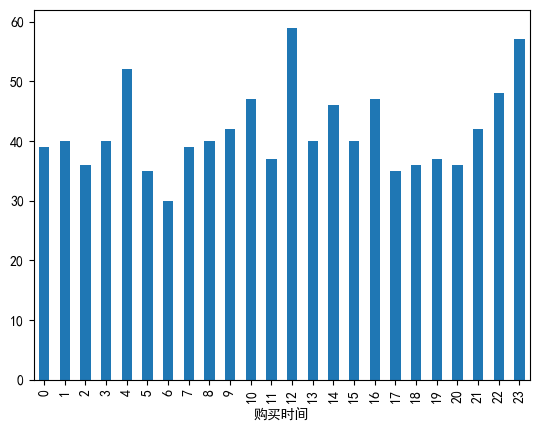

In [37]:
# 用户的交易集中时间再10-11点，以及22-23点 交易更集中
data_hour.plot(kind='bar')

### 省份


In [38]:
display(df,df['用户城市'].value_counts())

,用户ID,用户姓名,商品ID,商品名称,商品类别,单价,购买时间,购买数量,消费金额,用户城市,用户性别,用户年龄
0,U7559,施光善,P32724,香水,美妆,809.99,2024-08-15 13:24:49,2,1619.98,成都,女,28
1,U5784,华军盛,P38500,篮球,运动,436.85,2024-07-08 22:34:38,1,436.85,深圳,男,31
2,U3309,唐子,P72120,芭比娃娃,玩具,649.23,2024-09-03 12:14:14,1,649.23,北京,男,51
3,U2872,闵功,P68477,毛绒玩具,玩具,674.04,2024-03-11 09:12:45,4,2696.16,深圳,女,31
4,U3141,谢乐平,P14776,笔记本电脑,电子产品,3759.34,2024-08-22 06:16:49,4,15037.36,西安,男,33
...,...,...,...,...,...,...,...,...,...,...,...,...
995,U7369,米启全,P12203,夹克,服装,357.90,2024-03-01 08:41:36,4,1431.60,重庆,男,47
996,U6178,郁风胜,P44643,充电宝,电子产品,7485.52,2024-01-23 15:17:22,1,7485.52,苏州,女,51
997,U1133,和思,P83410,历史书籍,书籍,374.41,2024-02-05 18:44:36,1,374.41,西安,男,47
998,U3203,龚岩俊,P56885,瑜伽垫,运动,468.29,2024-01-20 19:55:29,3,1404.87,广州,男,42


用户城市
重庆    100
成都     97
苏州     94
武汉     92
杭州     82
深圳     80
上海     80
北京     79
天津     79
西安     75
南京     71
广州     71
Name: count, dtype: int64

In [39]:
# 每一个城市的消费总额
df.groupby('用户城市')['消费金额'].sum().sort_values(ascending=False)

用户城市
北京    390121.35
重庆    374027.87
苏州    353516.84
成都    341649.21
深圳    339252.09
南京    335056.77
西安    331320.34
武汉    320017.84
杭州    317127.90
广州    311092.94
上海    299174.62
天津    276383.16
Name: 消费金额, dtype: float64

### 年龄分析

In [40]:
df

,用户ID,用户姓名,商品ID,商品名称,商品类别,单价,购买时间,购买数量,消费金额,用户城市,用户性别,用户年龄
0,U7559,施光善,P32724,香水,美妆,809.99,2024-08-15 13:24:49,2,1619.98,成都,女,28
1,U5784,华军盛,P38500,篮球,运动,436.85,2024-07-08 22:34:38,1,436.85,深圳,男,31
2,U3309,唐子,P72120,芭比娃娃,玩具,649.23,2024-09-03 12:14:14,1,649.23,北京,男,51
3,U2872,闵功,P68477,毛绒玩具,玩具,674.04,2024-03-11 09:12:45,4,2696.16,深圳,女,31
4,U3141,谢乐平,P14776,笔记本电脑,电子产品,3759.34,2024-08-22 06:16:49,4,15037.36,西安,男,33
...,...,...,...,...,...,...,...,...,...,...,...,...
995,U7369,米启全,P12203,夹克,服装,357.90,2024-03-01 08:41:36,4,1431.60,重庆,男,47
996,U6178,郁风胜,P44643,充电宝,电子产品,7485.52,2024-01-23 15:17:22,1,7485.52,苏州,女,51
997,U1133,和思,P83410,历史书籍,书籍,374.41,2024-02-05 18:44:36,1,374.41,西安,男,47
998,U3203,龚岩俊,P56885,瑜伽垫,运动,468.29,2024-01-20 19:55:29,3,1404.87,广州,男,42


In [41]:
# 1. 生成透视表（如果之前没运行）
data = df.groupby(['用户性别', '商品类别'])['消费金额'].mean().reset_index()
pivot_df = data.pivot_table(index='商品类别', columns='用户性别', values='消费金额')

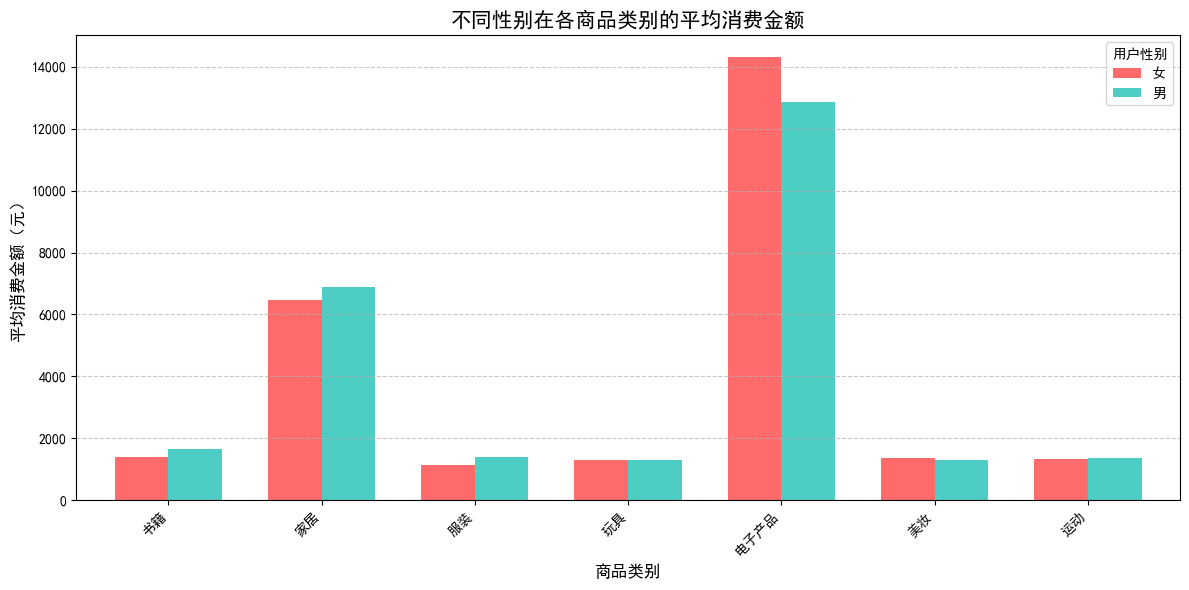

In [42]:

pivot_df = data.pivot_table(index='商品类别', columns='用户性别', values='消费金额')

# 绘制柱形图
pivot_df.plot(
    kind='bar',       # 图表类型：柱形图
    figsize=(12, 6),  # 图表大小
    width=0.7,        # 柱子宽度
    color=['#FF6B6B', '#4ECDC4']  # 颜色：女-红色，男-青色
)

# 添加图表元素
plt.title('不同性别在各商品类别的平均消费金额', fontsize=15)  # 标题
plt.xlabel('商品类别', fontsize=12)                         # x轴标签
plt.ylabel('平均消费金额（元）', fontsize=12)                # y轴标签
plt.xticks(rotation=45, ha='right')                         # x轴标签旋转45度，避免重叠
plt.legend(title='用户性别', fontsize=10)                   # 图例
plt.grid(axis='y', linestyle='--', alpha=0.7)               # y轴网格线

# 显示图表
plt.tight_layout()  # 自动调整布局
plt.show()

## RFM分群
RFM评价指标需要根据每一个维度 找到一个核心的，评价标准来衡量用户的好坏

In [43]:
df.head()

,用户ID,用户姓名,商品ID,商品名称,商品类别,单价,购买时间,购买数量,消费金额,用户城市,用户性别,用户年龄
0,U7559,施光善,P32724,香水,美妆,809.99,2024-08-15 13:24:49,2,1619.98,成都,女,28
1,U5784,华军盛,P38500,篮球,运动,436.85,2024-07-08 22:34:38,1,436.85,深圳,男,31
2,U3309,唐子,P72120,芭比娃娃,玩具,649.23,2024-09-03 12:14:14,1,649.23,北京,男,51
3,U2872,闵功,P68477,毛绒玩具,玩具,674.04,2024-03-11 09:12:45,4,2696.16,深圳,女,31
4,U3141,谢乐平,P14776,笔记本电脑,电子产品,3759.34,2024-08-22 06:16:49,4,15037.36,西安,男,33


In [44]:
category_agg = df.groupby('用户ID').agg(
    消费次数=('用户ID', 'count'),    
    最近消费时间=('购买时间', 'max'),
    累计消费金额=('消费金额', 'sum')
).reset_index()
category_agg

,用户ID,消费次数,最近消费时间,累计消费金额
0,U1024,1,2024-08-29 13:39:19,2344.59
1,U1028,1,2024-08-22 10:24:16,2352.24
2,U1029,1,2024-07-09 12:01:30,28486.00
3,U1035,1,2024-01-10 15:32:43,1554.14
4,U1051,1,2024-05-03 16:53:22,737.28
...,...,...,...,...
954,U9959,1,2024-02-29 16:20:12,130.20
955,U9960,1,2024-04-14 10:55:19,1137.56
956,U9964,1,2024-12-15 16:55:33,3629.60
957,U9981,1,2024-05-03 14:58:04,20135.84


In [45]:
bins = [0, 30, 100, 200, 300, float('inf')]  # float('inf')表示大于300天的所有值
labels = [5, 4, 3, 2, 1]  # 0-30→5，30-100→4，100-200→3，200-300→2，>300→1


category_agg['R']=(category_agg['最近消费时间'].max()-category_agg['最近消费时间']).dt.days
# 4. 执行区间分类
category_agg['R'] = pd.cut(
    x=(category_agg['最近消费时间'].max()-category_agg['最近消费时间']).dt.days,  # 要分类的列
    bins=bins,                 # 定义的区间
    labels=labels,             # 区间对应的标签
    include_lowest=True,       # 包含区间的最小值（比如0）
    right=False                # 区间左闭右开（关键！确保30属于30-100区间，而非0-30）
)
category_agg

,用户ID,消费次数,最近消费时间,累计消费金额,R
0,U1024,1,2024-08-29 13:39:19,2344.59,3
1,U1028,1,2024-08-22 10:24:16,2352.24,3
2,U1029,1,2024-07-09 12:01:30,28486.00,3
3,U1035,1,2024-01-10 15:32:43,1554.14,1
4,U1051,1,2024-05-03 16:53:22,737.28,2
...,...,...,...,...,...
954,U9959,1,2024-02-29 16:20:12,130.20,1
955,U9960,1,2024-04-14 10:55:19,1137.56,2
956,U9964,1,2024-12-15 16:55:33,3629.60,5
957,U9981,1,2024-05-03 14:58:04,20135.84,2


In [46]:
bins = [0, 1.1, 2.1, 3.1, 4.1, float('inf')]  # float('inf')表示大于300天的所有值
labels = [1,2,3,4,5]  # 0-30→5，30-100→4，100-200→3，200-300→2，>300→1


# 4. 执行区间分类
category_agg['F'] = pd.cut(
    x=category_agg['消费次数'],  # 要分类的列
    bins=bins,                 # 定义的区间
    labels=labels,             # 区间对应的标签
    include_lowest=True,       # 包含区间的最小值（比如0）
    right=False                # 区间左闭右开（关键！确保30属于30-100区间，而非0-30）
)
category_agg


,用户ID,消费次数,最近消费时间,累计消费金额,R,F
0,U1024,1,2024-08-29 13:39:19,2344.59,3,1
1,U1028,1,2024-08-22 10:24:16,2352.24,3,1
2,U1029,1,2024-07-09 12:01:30,28486.00,3,1
3,U1035,1,2024-01-10 15:32:43,1554.14,1,1
4,U1051,1,2024-05-03 16:53:22,737.28,2,1
...,...,...,...,...,...,...
954,U9959,1,2024-02-29 16:20:12,130.20,1,1
955,U9960,1,2024-04-14 10:55:19,1137.56,2,1
956,U9964,1,2024-12-15 16:55:33,3629.60,5,1
957,U9981,1,2024-05-03 14:58:04,20135.84,2,1


In [47]:
bins = [0, 1000, 2000, 3000, 4000, float('inf')]  # float('inf')表示大于300天的所有值
labels = [1,2,3,4,5]  # 0-30→5，30-100→4，100-200→3，200-300→2，>300→1


# 4. 执行区间分类
category_agg['M'] = pd.cut(
    x=category_agg['累计消费金额'],  # 要分类的列
    bins=bins,                 # 定义的区间
    labels=labels,             # 区间对应的标签
    include_lowest=True,       # 包含区间的最小值（比如0）
    right=False                # 区间左闭右开（关键！确保30属于30-100区间，而非0-30）
)
category_agg


,用户ID,消费次数,最近消费时间,累计消费金额,R,F,M
0,U1024,1,2024-08-29 13:39:19,2344.59,3,1,3
1,U1028,1,2024-08-22 10:24:16,2352.24,3,1,3
2,U1029,1,2024-07-09 12:01:30,28486.00,3,1,5
3,U1035,1,2024-01-10 15:32:43,1554.14,1,1,2
4,U1051,1,2024-05-03 16:53:22,737.28,2,1,1
...,...,...,...,...,...,...,...
954,U9959,1,2024-02-29 16:20:12,130.20,1,1,1
955,U9960,1,2024-04-14 10:55:19,1137.56,2,1,2
956,U9964,1,2024-12-15 16:55:33,3629.60,5,1,4
957,U9981,1,2024-05-03 14:58:04,20135.84,2,1,5


In [48]:
category_agg['R'] = category_agg['R'].astype(int)
category_agg['F'] = category_agg['F'].astype(int)
category_agg['M'] = category_agg['M'].astype(int)

# 步骤2：再计算平均值（此时无报错）
r_avg = category_agg['R'].mean()
f_avg = category_agg['F'].mean()
m_avg = category_agg['M'].mean()
display(r_avg,f_avg,m_avg)

np.float64(2.7632950990615224)

np.float64(1.0427528675703859)

np.float64(2.670490093847758)

In [49]:
category_agg['R值高低'] = np.where(category_agg['R'] > r_avg, '高', '低')
category_agg['F值高低'] = np.where(category_agg['F'] > f_avg, '高', '低')
category_agg['M值高低'] = np.where(category_agg['M'] > m_avg, '高', '低')
category_agg

,用户ID,消费次数,最近消费时间,累计消费金额,R,F,M,R值高低,F值高低,M值高低
0,U1024,1,2024-08-29 13:39:19,2344.59,3,1,3,高,低,高
1,U1028,1,2024-08-22 10:24:16,2352.24,3,1,3,高,低,高
2,U1029,1,2024-07-09 12:01:30,28486.00,3,1,5,高,低,高
3,U1035,1,2024-01-10 15:32:43,1554.14,1,1,2,低,低,低
4,U1051,1,2024-05-03 16:53:22,737.28,2,1,1,低,低,低
...,...,...,...,...,...,...,...,...,...,...
954,U9959,1,2024-02-29 16:20:12,130.20,1,1,1,低,低,低
955,U9960,1,2024-04-14 10:55:19,1137.56,2,1,2,低,低,低
956,U9964,1,2024-12-15 16:55:33,3629.60,5,1,4,高,低,高
957,U9981,1,2024-05-03 14:58:04,20135.84,2,1,5,低,低,高


In [50]:
conditions = [
    # 重要价值用户：R高、F高、M高
    (category_agg['R'] > r_avg) & (category_agg['F'] > f_avg) & (category_agg['M'] > m_avg),
    # 重要保持用户：R低、F高、M高
    (category_agg['R'] <= r_avg) & (category_agg['F'] > f_avg) & (category_agg['M'] > m_avg),
    # 重要发展用户：R高、F低、M高
    (category_agg['R'] > r_avg) & (category_agg['F'] <= f_avg) & (category_agg['M'] > m_avg),
    # 重要挽留用户：R低、F低、M高
    (category_agg['R'] <= r_avg) & (category_agg['F'] <= f_avg) & (category_agg['M'] > m_avg),
    # 一般价值用户：R高、F高、M低
    (category_agg['R'] > r_avg) & (category_agg['F'] > f_avg) & (category_agg['M'] <= m_avg),
    # 一般保持用户：R低、F高、M低
    (category_agg['R'] <= r_avg) & (category_agg['F'] > f_avg) & (category_agg['M'] <= m_avg),
    # 一般发展用户：R高、F低、M低
    (category_agg['R'] > r_avg) & (category_agg['F'] <= f_avg) & (category_agg['M'] <= m_avg),
    # 一般挽留用户：R低、F低、M低
    (category_agg['R'] <= r_avg) & (category_agg['F'] <= f_avg) & (category_agg['M'] <= m_avg)
]

# --------------------------
# 4. 定义每个条件对应的用户分层名称
# --------------------------
choices = [
    '重要价值用户',
    '重要保持用户',
    '重要发展用户',
    '重要挽留用户',
    '一般价值用户',
    '一般保持用户',
    '一般发展用户',
    '一般挽留用户'
]

# --------------------------
# 5. 生成最终的用户价值分层列（新增到 category_agg 中）
# --------------------------
category_agg['用户价值分层'] = np.select(
    condlist=conditions,
    choicelist=choices,
    default='未分类用户'  # 显式指定默认值，且为字符串，和choices类型一致
)
category_agg

,用户ID,消费次数,最近消费时间,累计消费金额,R,F,M,R值高低,F值高低,M值高低,用户价值分层
0,U1024,1,2024-08-29 13:39:19,2344.59,3,1,3,高,低,高,重要发展用户
1,U1028,1,2024-08-22 10:24:16,2352.24,3,1,3,高,低,高,重要发展用户
2,U1029,1,2024-07-09 12:01:30,28486.00,3,1,5,高,低,高,重要发展用户
3,U1035,1,2024-01-10 15:32:43,1554.14,1,1,2,低,低,低,一般挽留用户
4,U1051,1,2024-05-03 16:53:22,737.28,2,1,1,低,低,低,一般挽留用户
...,...,...,...,...,...,...,...,...,...,...,...
954,U9959,1,2024-02-29 16:20:12,130.20,1,1,1,低,低,低,一般挽留用户
955,U9960,1,2024-04-14 10:55:19,1137.56,2,1,2,低,低,低,一般挽留用户
956,U9964,1,2024-12-15 16:55:33,3629.60,5,1,4,高,低,高,重要发展用户
957,U9981,1,2024-05-03 14:58:04,20135.84,2,1,5,低,低,高,重要挽留用户


## 优惠卷推送
平台推出不同价格的代金券，用于发放给全量用户，请根据用户的交易行为完成特征构造，并进行客户价值分析，推动此活动。
背景：
- 三种优惠卷：5,10,15这几张面额的优惠卷
- 给每一种人送优惠卷。

### 评分模型
- 评分模型:针对于用户的每一个维度进行打分，与rfm不同的是评分模型能考量的维度更多了，那么也一定会更精准一些
- 风险:会让数据更离散化（维度没有权重）

In [54]:
category_agg['用户价值分层'].value_counts()

用户价值分层
一般发展用户    278
一般挽留用户    247
重要发展用户    223
重要挽留用户    173
重要价值用户     26
一般价值用户      6
一般保持用户      3
重要保持用户      3
Name: count, dtype: int64

In [55]:
df.head()

,用户ID,用户姓名,商品ID,商品名称,商品类别,单价,购买时间,购买数量,消费金额,用户城市,用户性别,用户年龄
0,U7559,施光善,P32724,香水,美妆,809.99,2024-08-15 13:24:49,2,1619.98,成都,女,28
1,U5784,华军盛,P38500,篮球,运动,436.85,2024-07-08 22:34:38,1,436.85,深圳,男,31
2,U3309,唐子,P72120,芭比娃娃,玩具,649.23,2024-09-03 12:14:14,1,649.23,北京,男,51
3,U2872,闵功,P68477,毛绒玩具,玩具,674.04,2024-03-11 09:12:45,4,2696.16,深圳,女,31
4,U3141,谢乐平,P14776,笔记本电脑,电子产品,3759.34,2024-08-22 06:16:49,4,15037.36,西安,男,33
